In [ ]:
###############################
#UXARRAY CODE GUIDE
#https://uxarray.readthedocs.io/en/latest/user-guide/
###############################

In [ ]:
#LIBRARIES
import os
import glob
import numpy as np

import matplotlib.pyplot as plt

In [2]:
#GETTING XARRAY
import xarray as xr

#GETTING UXARRAY
import uxarray as ux
import cartopy.crs as ccrs
import geoviews.feature as gf
import holoviews as hv

In [ ]:
#################################################

In [3]:
# Directory path
model_directory = "/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.1/MPAS-Model_Global"
static_directory = os.path.join(model_directory,"x1.10242.static.nc")

In [4]:
#GETTING FILE LIST



directory=model_directory
FileList = np.sort([f for f in os.listdir(directory) if f.startswith("history")])
FilePathList = np.sort([
    os.path.join(directory, f) 
    for f in os.listdir(directory) if f.startswith("history")
])
print("Files with prefix 'history':")
for f in FileList:
    print(f)

Files with prefix 'history':
history.2022-06-30_00.00.00.nc
history.2022-06-30_06.00.00.nc
history.2022-06-30_12.00.00.nc
history.2022-06-30_18.00.00.nc
history.2022-07-01_00.00.00.nc
history.2022-07-01_06.00.00.nc
history.2022-07-01_12.00.00.nc
history.2022-07-01_18.00.00.nc
history.2022-07-02_00.00.00.nc
history.2022-07-02_06.00.00.nc
history.2022-07-02_12.00.00.nc
history.2022-07-02_18.00.00.nc
history.2022-07-03_00.00.00.nc


In [5]:
#OPENING UNSTRUCTURED MODEL DATA

In [6]:
#getting grid info
primal_mesh = ux.open_grid(static_directory, use_dual=False)
dual_mesh = ux.open_grid(static_directory, use_dual=True)

In [7]:
# #how to open a single file

# FilePath = FilePathList[7]

# # This will return a uxarray.UxDataset
# ds1 = ux.open_dataset(grid_filename_or_obj=static_directory,
#                      filename_or_obj=FilePath)

In [8]:
#how to open all files
ds1 = ux.open_mfdataset(grid_filename_or_obj=static_directory,
                       paths=FilePathList)

In [9]:
#SELECTING DATA

In [10]:
ds2=ds1.sel(Time="2022-07-01T18:00:00", method="nearest")
ds3=ds2.isel(nVertLevels=0)
variable=ds3['surface_pressure']

In [11]:
######################################
#SUBSETTING DATA

In [12]:
#SUBSET ALL

In [13]:
variable.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [14]:
#SUBSET LATLON BOUNDS

In [15]:
# Example: Define a bounding box
lon_bounds = (-150, -50)  # Longitude from -100 to -70
lat_bounds = (0, 90)     # Latitude from 25 to 45

# Subset the UxDataArray
variable_subset = variable.subset.bounding_box(lon_bounds=lon_bounds, lat_bounds=lat_bounds)
variable_subset

<xarray.UxDataArray 'surface_pressure' (n_face: 1327)> Size: 5kB
dask.array<getitem, shape=(1327,), dtype=float32, chunksize=(1327,), chunktype=numpy.ndarray>
Coordinates:
    Time     datetime64[ns] 8B 2022-07-01T18:00:00
Dimensions without coordinates: n_face
Attributes:
    units:      Pa
    long_name:  Diagnosed surface pressure

In [16]:
variable_subset.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [17]:
#SUBSET: BOUNDING BOX

In [18]:
#box bounding region

variable_BoundingBox = variable.subset.bounding_box(
    lon_bounds,
    lat_bounds,
)
variable_BoundingBox.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

:Image   [x,y]   (x_y surface_pressure)
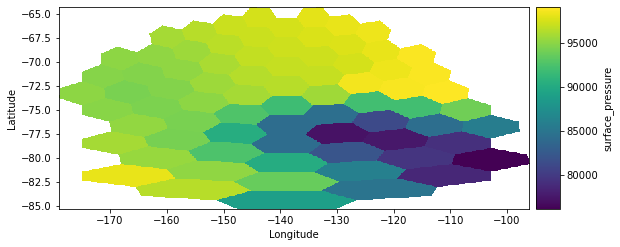

In [103]:
#circular bounding region
center_coord = (40, -105)
r=10 #number of grids

variable_BoundingCircle = variable.subset.bounding_circle(center_coord, r)
variable_BoundingCircle.plot(cmap='viridis')

In [21]:
#SUBSET: NEAREST NEIGHBORS

In [22]:
#subset single point

# Define your target point
target_lon, target_lat = -95.0, 30.0
center_coord = (target_lon, target_lat)

# Get nearest face to that point
variable_Point = variable.subset.nearest_neighbor(center_coord, k=1, element='face centers')
# variable_Nearest.plot()
variable_Point.data.compute()


array([100970.43], dtype=float32)

In [23]:
#subset nearest neighbor

# Define your target point
target_lon, target_lat = -95.0, 30.0
center_coord = (target_lon, target_lat)

# Get nearest face to that point
variable_Nearest = variable.subset.nearest_neighbor(center_coord, k=30, element='face centers') #element='nodes'
variable_Nearest.plot()
# variable_Point.data.compute()



:Image   [x,y]   (x_y surface_pressure)

In [24]:
#SUBSET: CONSTANT LATLON LINES

In [25]:
target_lat = 40.0
variable_subset_ConstLat=variable_subset.subset.constant_latitude(target_lat) #finds all faces that constant latitude line passes through
variable_subset_ConstLat.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [26]:
target_lat = -105
variable_subset_ConstLon=variable_subset.subset.constant_longitude(target_lat) #finds all faces that constant latitude line passes through
variable_subset_ConstLon.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [27]:
target_lat = -105
variable_subset_ConstLon=variable_subset.subset.constant_longitude(target_lat) #finds all faces that constant latitude line passes through
variable_subset_ConstLon.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [28]:
#SUBSET: CONSTANT LATLON SLICES

In [29]:
#subsetting longitude interval
lons=(-150,-50)
variable_LonInterval=variable_subset.subset.constant_longitude_interval(lons)
variable_LonInterval.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [30]:
#subsetting latitude interval
lats = (-50, 50)
variable_LatInterval=variable.subset.constant_latitude_interval(lats)
variable_LatInterval.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [31]:
#CHECKING IF GRID IS A SUBSET

In [32]:
variable_subset.uxgrid.is_subset

True

In [33]:
######################################
#PLOTTING

In [34]:
#basic plot
variable.plot(cmap='viridis')

:Image   [x,y]   (x_y surface_pressure)

In [35]:
#plot with border data

In [36]:
#Plot Settings
plot_opts = {"width": 700, "height": 350}
features = gf.coastline(
    projection=ccrs.PlateCarree(), line_width=1, scale="50m"
) * gf.states(projection=ccrs.PlateCarree(), line_width=1, scale="50m")
clim = (variable.values.min(), variable.values.max())

#Running Plots
variable.plot(
    rasterize=True,
    periodic_elements="exclude",
    clim=clim,
    cmap='viridis',
    title="",
    **plot_opts,
) * features


:Overlay
   .Image.I     :Image   [x,y]   (x_y surface_pressure)
   .Coastline.I :Feature   [Longitude,Latitude]
   .States.I    :Feature   [Longitude,Latitude]

In [37]:
#COMBINING PLOTS (EXAMPLE)

In [38]:
# (
#     uxds["psi"].plot(
#         cmap="inferno",
#         periodic_elements="split",
#         height=250,
#         width=500,
#         colorbar=False,
#         ylim=(-90, 90),
#     )
#     + zonal_mean_psi.plot.line(
#         x="psi_zonal_mean",
#         y="latitudes",
#         height=250,
#         width=150,
#         ylabel="",
#         ylim=(-90, 90),
#         xlim=(0.8, 1.2),
#         xticks=[0.8, 0.9, 1.0, 1.1, 1.2],
#         yticks=[-90, -45, 0, 45, 90],
#         grid=True,
#     )
# ).opts(title="Combined Zonal Average & Raster Plot")

In [39]:
######################################
#CROSS SECTIONS
variable2=ds2["qv"]

In [40]:
#Helper Function
def set_lon_lat_xticks(ax, cross_section, n_ticks=6):
    """Utility function to draw stacked lat/lon points along the sampled cross-section"""
    da = cross_section

    N = da.sizes["steps"]
    tick_pos = np.linspace(0, N - 1, n_ticks, dtype=int)
    lons = da["lon"].values[tick_pos]
    lats = da["lat"].values[tick_pos]

    tick_labels = []
    for lon, lat in zip(lons, lats):
        lon_dir = "E" if lon >= 0 else "W"
        lat_dir = "N" if lat >= 0 else "S"
        tick_labels.append(f"{abs(lon):.2f}°{lon_dir}\n{abs(lat):.2f}°{lat_dir}")

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels)

    ax.set_xlabel("Longitude\nLatitude")
    plt.tight_layout()

    return fig, ax

In [41]:
#GREAT CIRCLE CROSS SECTION #*#*

Text(0.5, 1.0, 'Cross Section between (-45, -45) and (45, 45)')

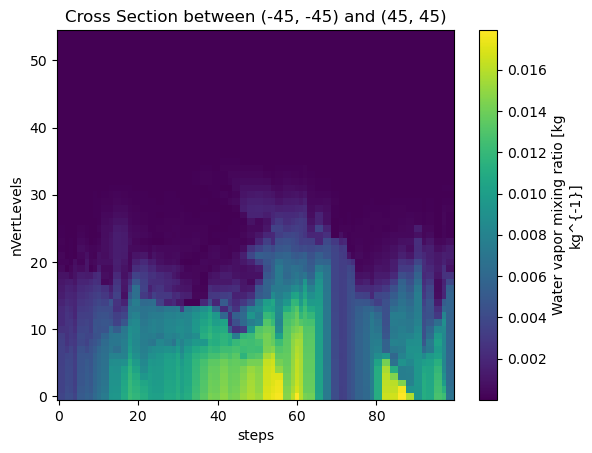

In [42]:

start_point = (-45, -45)
end_point = (45, 45)

cross_section_gca = variable2.cross_section(
    start=start_point, end=end_point, steps=100
)

fig, ax = plt.subplots()
cross_section_gca.T.plot(ax=ax)

# set_lon_lat_xticks(ax, cross_section_gca)
ax.set_title(f"Cross Section between {start_point} and {end_point}")

In [43]:
#CONSTANT LATLON CROSS SECTION #*#*

Text(0.5, 1.0, 'Cross Section at 0° latitude.')

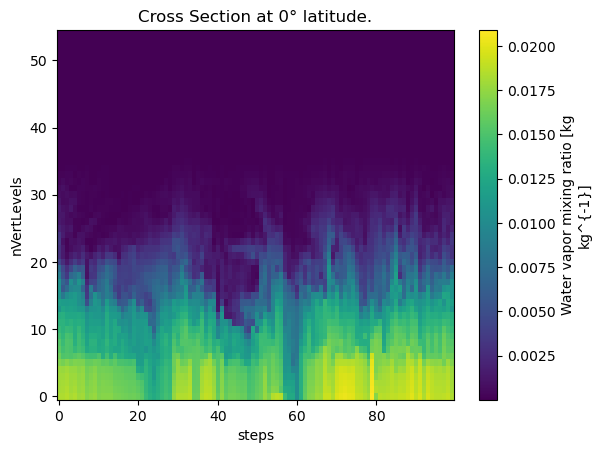

In [44]:
#constant latitude
lat = 0
cross_section_const_lat = variable2.cross_section(lat=lat, steps=100)

fig, ax = plt.subplots()
cross_section_const_lat.T.plot(ax=ax)

# set_lon_lat_xticks(ax, cross_section_const_lat)
ax.set_title(f"Cross Section at {lat}° latitude.")

Text(0.5, 1.0, 'Cross Section at 0° latitude.')

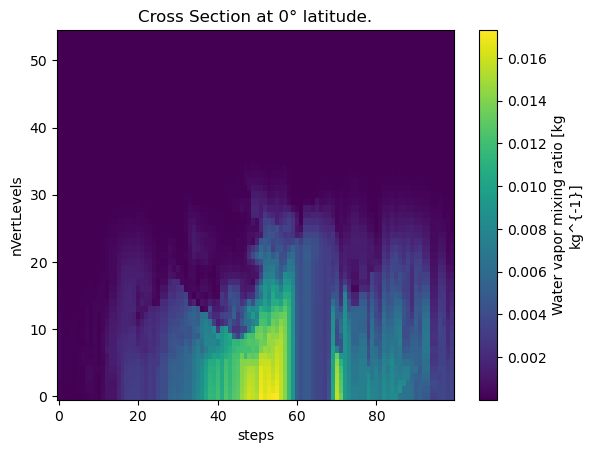

In [45]:
#constant longitude
lon = 0
cross_section_const_lon = variable2.cross_section(lon=lon, steps=100)

fig, ax = plt.subplots()
cross_section_const_lon.T.plot(ax=ax)

# set_lon_lat_xticks(ax, cross_section_const_lon)
ax.set_title(f"Cross Section at {lat}° latitude.")

In [46]:
######################################
#ZONAL AVERAGING

In [47]:
# ZONAL MEAN

In [48]:
variable_ZonalMean = variable2.zonal_mean()
variable_ZonalMean.compute()

<xarray.UxDataArray 'qv_zonal_mean' (latitudes: 19, nVertLevels: 55)> Size: 4kB
array([[1.36037306e-05, 1.04091501e-04, 1.19406606e-04, ...,
        3.64093125e-06, 3.52918937e-06, 4.35691572e-06],
       [1.25522944e-04, 1.89860322e-04, 2.43271337e-04, ...,
        3.80051506e-06, 3.98626753e-06, 4.06664276e-06],
       [7.55468907e-04, 7.75656838e-04, 7.88525154e-04, ...,
        3.90844298e-06, 4.15862451e-06, 4.15547947e-06],
       ...,
       [5.34448586e-03, 5.56784822e-03, 5.48073649e-03, ...,
        3.57455133e-06, 4.10468101e-06, 4.52069571e-06],
       [3.60419741e-03, 3.58838099e-03, 3.55874887e-03, ...,
        3.57671115e-06, 4.13713860e-06, 4.58488103e-06],
       [1.15491385e-02, 1.14007350e-02, 1.13260895e-02, ...,
        3.35477262e-06, 3.61776142e-06, 3.75091804e-06]], dtype=float32)
Coordinates:
  * latitudes  (latitudes) int64 152B -90 -80 -70 -60 -50 -40 ... 50 60 70 80 90
Dimensions without coordinates: nVertLevels
Attributes:
    zonal_mean:  True

In [49]:
(variable_ZonalMean.plot.line()).opts(
    title="Zonal Average Plot (Default)", xticks=np.arange(-90, 100, 20), xlim=(-95, 95)
)

:Curve   [latitudes]   (qv_zonal_mean)

In [50]:
#ZONAL MEAN (WITH RANGE OF LATITUDES)

In [51]:
variable_ZonalMean = variable2.zonal_mean(lat=(-90, 90, 1))
variable_ZonalMean.compute()

<xarray.UxDataArray 'qv_zonal_mean' (latitudes: 181, nVertLevels: 55)> Size: 40kB
array([[1.36037306e-05, 1.04091501e-04, 1.19406606e-04, ...,
        3.64093125e-06, 3.52918937e-06, 4.35691572e-06],
       [1.69421673e-05, 9.11997704e-05, 1.13566457e-04, ...,
        3.65147935e-06, 3.54239705e-06, 4.34145522e-06],
       [2.13147778e-05, 7.87460376e-05, 1.08383472e-04, ...,
        3.66258359e-06, 3.55700786e-06, 4.32231309e-06],
       ...,
       [3.56783136e-03, 3.52067128e-03, 3.46449949e-03, ...,
        3.53408132e-06, 4.01786292e-06, 4.39527139e-06],
       [3.62074072e-03, 3.57968826e-03, 3.52825201e-03, ...,
        3.53612086e-06, 4.02201340e-06, 4.39266023e-06],
       [1.15491385e-02, 1.14007350e-02, 1.13260895e-02, ...,
        3.35477262e-06, 3.61776142e-06, 3.75091804e-06]], dtype=float32)
Coordinates:
  * latitudes  (latitudes) int64 1kB -90 -89 -88 -87 -86 -85 ... 86 87 88 89 90
Dimensions without coordinates: nVertLevels
Attributes:
    zonal_mean:  True

In [52]:
(variable_ZonalMean.plot.line()).opts(
    title="Zonal Average Plot (Default)", xticks=np.arange(-90, 100, 20), xlim=(-95, 95)
)

:Curve   [latitudes]   (qv_zonal_mean)

In [53]:
######################################
#REMAPPING

In [112]:
import urllib.request

#loading data from uxarray
data_var = "bottomDepth"

grid_filename_480 = "oQU480.grid.nc"
data_filename_480 = "oQU480.data.nc"

grid_filename_120 = "oQU120.grid.nc"
data_filename_120 = "oQU120.data.nc"

filenames = [grid_filename_480, data_filename_480, grid_filename_120, data_filename_120]

for filename in filenames:
    if not os.path.isfile(filename):
        # downloads the files from Cookbook repo, if they haven't been downloaded locally yet
        url = f"https://github.com/ProjectPythia/unstructured-grid-viz-cookbook/raw/main/meshfiles/{filename}"
        _, headers = urllib.request.urlretrieve(url, filename=filename)


file_path_dict = {
    "480km": [grid_filename_480, data_filename_480],
    "120km": [grid_filename_120, data_filename_120],
}
uxds_480 = ux.open_dataset(*file_path_dict["480km"])
uxds_120 = ux.open_dataset(*file_path_dict["120km"])

:Layout
   .Overlay.I  :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.II :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
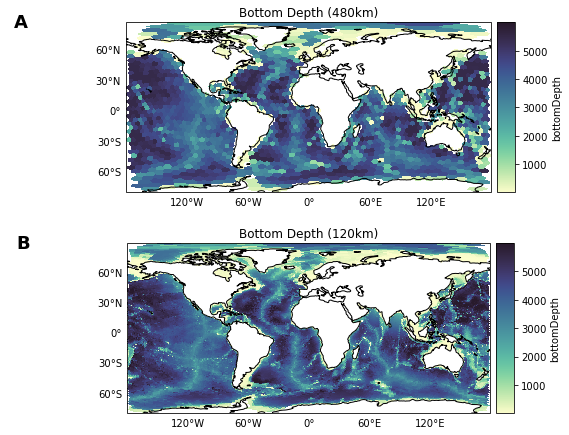

In [115]:
#plotting data
import cmocean
common_kwargs = {"cmap": cmocean.cm.deep, "features": ["coastline"]}
(
    uxds_480["bottomDepth"].plot(title="Bottom Depth (480km)", **common_kwargs)
    + uxds_120["bottomDepth"].plot(title="Bottom Depth (120km)", **common_kwargs)
).cols(1).opts(fig_size=200)

In [116]:
#view supported remapping methods
uxds_120.remap #nearest_neighbor and inverse_distance_weighted

<UxDataset.remap>
Supported methods:
  • nearest_neighbor(destination_grid, remap_to='faces')
  • inverse_distance_weighted(destination_grid, remap_to='faces', power=2, k=8)

In [ ]:
#NEAREST NEIGHBOR REMAPPING

:Layout
   .Overlay.I   :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.II  :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.III :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.IV  :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
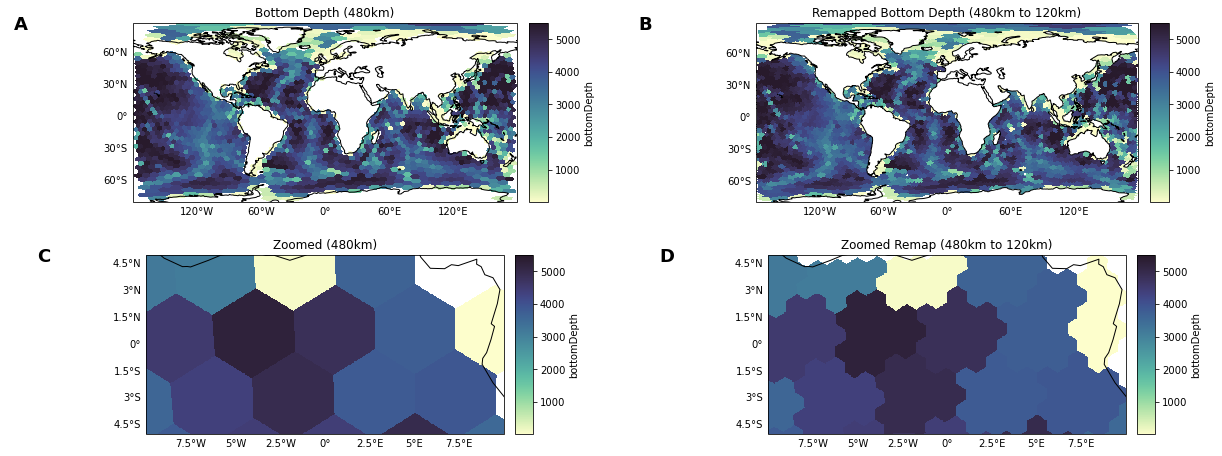

In [118]:
#upsampling (nearest neighbor)
upsampling = uxds_480["bottomDepth"].remap.nearest_neighbor(
    destination_grid=uxds_120.uxgrid, remap_to="faces"
)

#plotting
(
    uxds_480["bottomDepth"].plot(title="Bottom Depth (480km)", **common_kwargs)
    + upsampling.plot(title="Remapped Bottom Depth (480km to 120km)", **common_kwargs)
    + uxds_480["bottomDepth"].plot(
        title="Zoomed (480km)", xlim=(-10, 10), ylim=(-5, 5), **common_kwargs
    )
    + upsampling.plot(
        title="Zoomed Remap (480km to 120km)",
        xlim=(-10, 10),
        ylim=(-5, 5),
        **common_kwargs,
    )
).cols(2).opts(fig_size=200)

:Layout
   .Overlay.I   :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.II  :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.III :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.IV  :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
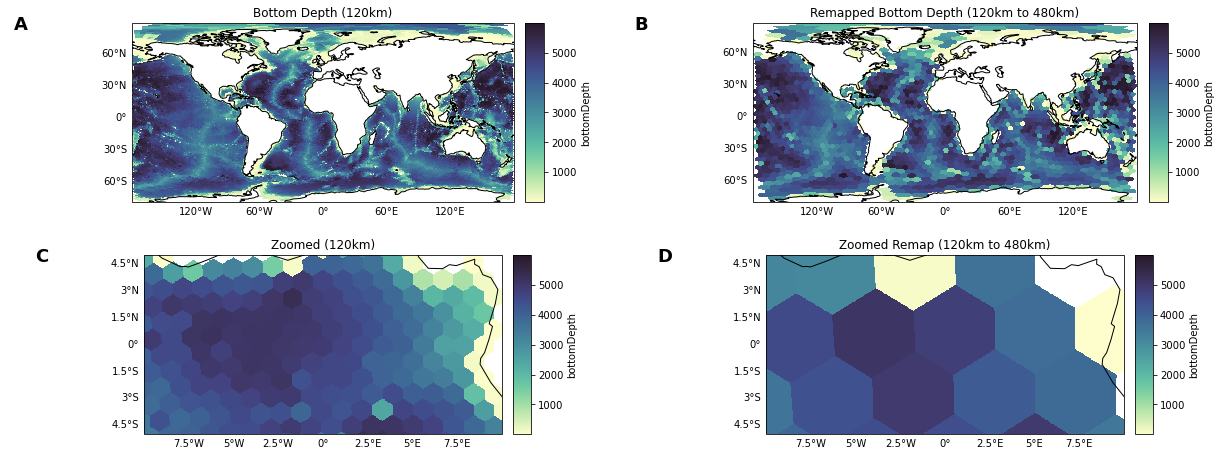

In [119]:
#downsampling (nearest neighbor)
downsampling = uxds_120["bottomDepth"].remap.nearest_neighbor(
    destination_grid=uxds_480.uxgrid, remap_to="face centers"
)

#plotting
(
    uxds_120["bottomDepth"].plot(title="Bottom Depth (120km)", **common_kwargs)
    + downsampling.plot(title="Remapped Bottom Depth (120km to 480km)", **common_kwargs)
    + uxds_120["bottomDepth"].plot(
        title="Zoomed (120km)", xlim=(-10, 10), ylim=(-5, 5), **common_kwargs
    )
    + downsampling.plot(
        title="Zoomed Remap (120km to 480km)",
        xlim=(-10, 10),
        ylim=(-5, 5),
        **common_kwargs,
    )
).cols(2).opts(fig_size=200)


In [ ]:
#INVERSE DISTANCE WEIGHTED REMAPPING

:Layout
   .Overlay.I   :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.II  :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.III :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.IV  :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
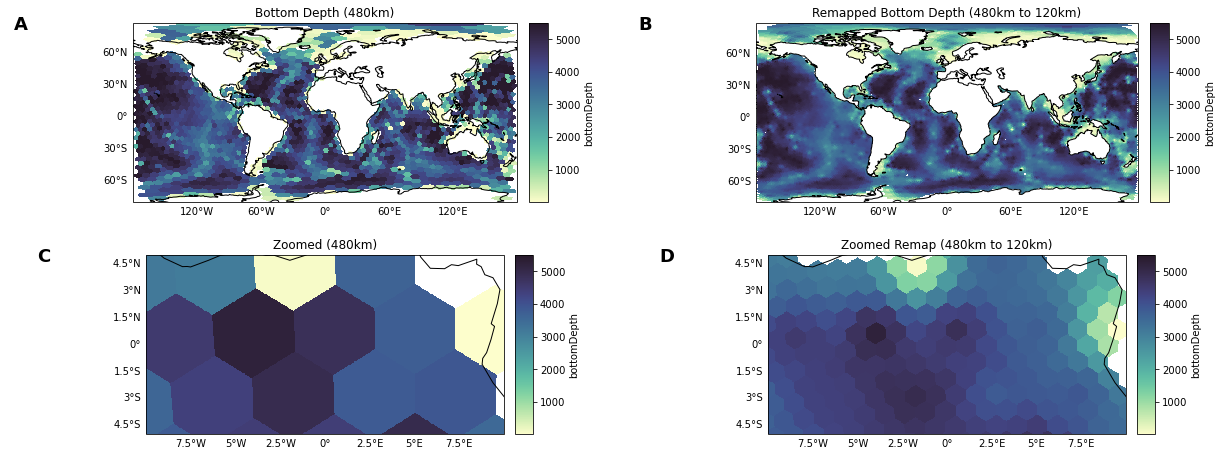

In [120]:
#upsampling (inverse distance weighted)

upsampling_idw = uxds_480["bottomDepth"].remap.inverse_distance_weighted(
    destination_grid=uxds_120.uxgrid, remap_to="faces"
)

#plotting
(
    uxds_480["bottomDepth"].plot(title="Bottom Depth (480km)", **common_kwargs)
    + upsampling_idw.plot(
        title="Remapped Bottom Depth (480km to 120km)", **common_kwargs
    )
    + uxds_480["bottomDepth"].plot(
        title="Zoomed (480km)", xlim=(-10, 10), ylim=(-5, 5), **common_kwargs
    )
    + upsampling_idw.plot(
        title="Zoomed Remap (480km to 120km)",
        xlim=(-10, 10),
        ylim=(-5, 5),
        **common_kwargs,
    )
).cols(2).opts(fig_size=200)

:Layout
   .Overlay.I   :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.II  :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.III :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.IV  :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
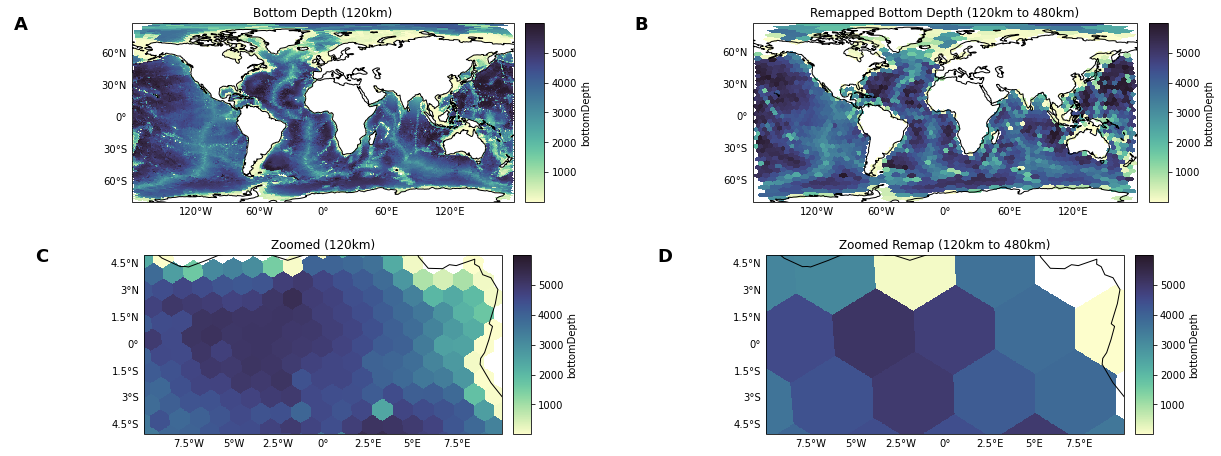

In [121]:
#downsampling (inverse distance weighted)
downsampling_idw = uxds_120["bottomDepth"].remap.inverse_distance_weighted(
    destination_grid=uxds_480.uxgrid, remap_to="faces"
)

#plotting
(
    uxds_120["bottomDepth"].plot(title="Bottom Depth (120km)", **common_kwargs)
    + downsampling_idw.plot(
        title="Remapped Bottom Depth (120km to 480km)", **common_kwargs
    )
    + uxds_120["bottomDepth"].plot(
        title="Zoomed (120km)", xlim=(-10, 10), ylim=(-5, 5), **common_kwargs
    )
    + downsampling_idw.plot(
        title="Zoomed Remap (120km to 480km)",
        xlim=(-10, 10),
        ylim=(-5, 5),
        **common_kwargs,
    )
).cols(2).opts(fig_size=200)

In [ ]:
#comparing k and power parameters
# 1. k
# The number of nearest neighbors included in the interpolation. Larger values draw from more source points, but the impact depends on how those points are weighted.

# 2.power
# The exponent that governs distance-decay in the weighting function. Higher exponents localize the interpolation by rapidly down-weighting more distant points.

:Layout
   .Overlay.I  :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.II :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
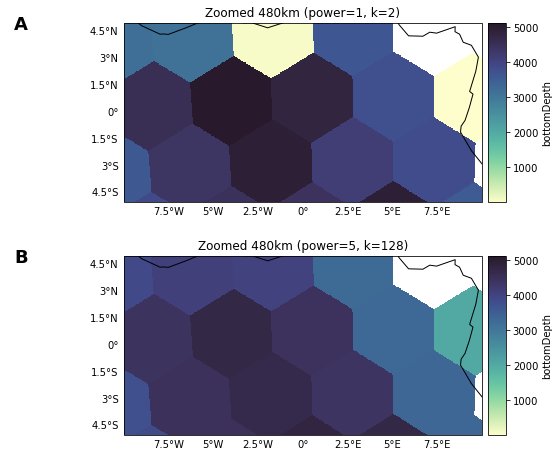

In [122]:
#comparison (downsampling)
downsampling_idw_low = uxds_120["bottomDepth"].remap.inverse_distance_weighted(
    uxds_480.uxgrid, remap_to="faces", power=1, k=2
)
downsampling_idw_high = uxds_120["bottomDepth"].remap.inverse_distance_weighted(
    uxds_480.uxgrid, remap_to="faces", power=5, k=128
)

#plotting
(
    downsampling_idw_low.plot(
        title="Zoomed 480km (power=1, k=2)",
        xlim=(-10, 10),
        ylim=(-5, 5),
        **common_kwargs,
    )
    + downsampling_idw_high.plot(
        title="Zoomed 480km (power=5, k=128)",
        xlim=(-10, 10),
        ylim=(-5, 5),
        **common_kwargs,
    )
).cols(1).opts(fig_size=200)

:Layout
   .Overlay.I  :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.II :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
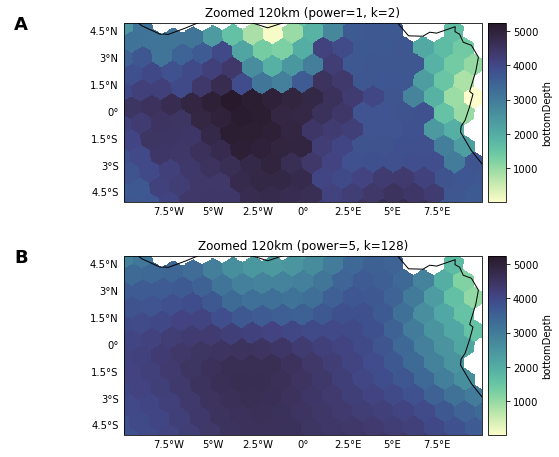

In [123]:
#comparison (upsampling)
upsampling_idw_low = uxds_480["bottomDepth"].remap.inverse_distance_weighted(
    uxds_120.uxgrid, remap_to="faces", power=1, k=2
)
upsampling_idw_high = uxds_480["bottomDepth"].remap.inverse_distance_weighted(
    uxds_120.uxgrid, remap_to="faces", power=5, k=128
)

#plotting
(
    upsampling_idw_low.plot(
        title="Zoomed 120km (power=1, k=2)",
        xlim=(-10, 10),
        ylim=(-5, 5),
        **common_kwargs,
    )
    + upsampling_idw_high.plot(
        title="Zoomed 120km (power=5, k=128)",
        xlim=(-10, 10),
        ylim=(-5, 5),
        **common_kwargs,
    )
).cols(1).opts(fig_size=200)

In [ ]:
#BILINEAR MAPPING

:Layout
   .Overlay.I   :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.II  :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.III :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
   .Overlay.IV  :Overlay
      .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude bottomDepth)
      .Coastline.I :Feature   [Longitude,Latitude]
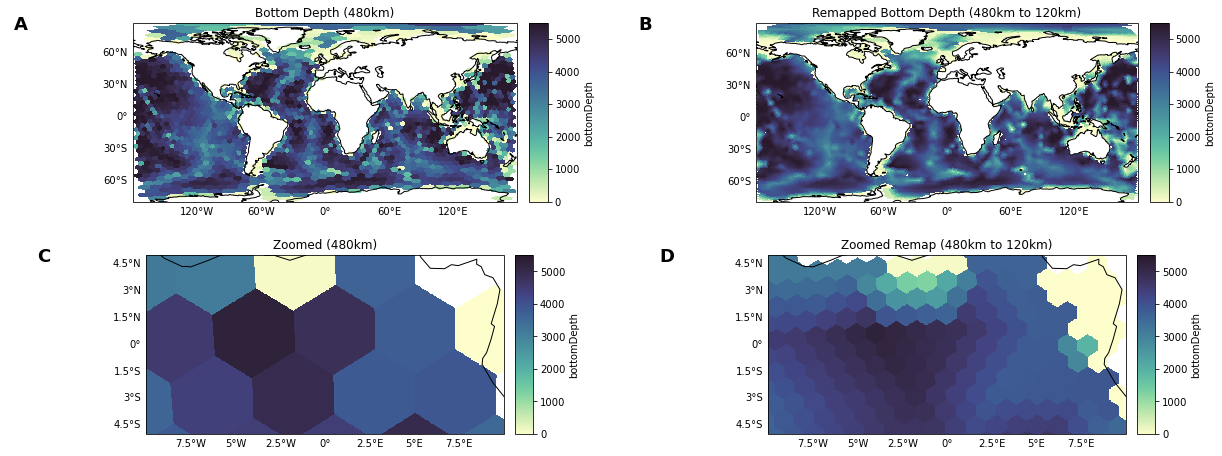

In [124]:
#upsampling (bilinear)
upsampling_bl = uxds_480["bottomDepth"].remap.bilinear(
    destination_grid=uxds_120.uxgrid, remap_to="faces"
)

#plotting
(
    uxds_480["bottomDepth"].plot(title="Bottom Depth (480km)", **common_kwargs)
    + upsampling_bl.plot(
        title="Remapped Bottom Depth (480km to 120km)", **common_kwargs
    )
    + uxds_480["bottomDepth"].plot(
        title="Zoomed (480km)", xlim=(-10, 10), ylim=(-5, 5), **common_kwargs
    )
    + upsampling_bl.plot(
        title="Zoomed Remap (480km to 120km)",
        xlim=(-10, 10),
        ylim=(-5, 5),
        **common_kwargs,
    )
).cols(2).opts(fig_size=200)

In [ ]:
#downsampling (bilinear)
downsampling_bl = uxds_120["bottomDepth"].remap.bilinear(
    destination_grid=uxds_480.uxgrid, remap_to="faces"
)

#plotting
(
    uxds_120["bottomDepth"].plot(title="Bottom Depth (120km)", **common_kwargs)
    + downsampling_bl.plot(
        title="Remapped Bottom Depth (120km to 480km)", **common_kwargs
    )
    + uxds_120["bottomDepth"].plot(
        title="Zoomed (120km)", xlim=(-10, 10), ylim=(-5, 5), **common_kwargs
    )
    + downsampling_bl.plot(
        title="Zoomed Remap (120km to 480km)",
        xlim=(-10, 10),
        ylim=(-5, 5),
        **common_kwargs,
    )
).cols(2).opts(fig_size=200)

In [ ]:
######################################
#GRADIENTS

In [108]:
# computing gradient
center_coord = (40, -105)
r=5 #number of grids

uxds=ds3

grad_lat = uxds["latCell"].subset.bounding_circle(center_coord, r).gradient()
grad_lon = uxds["lonCell"].subset.bounding_circle(center_coord, r).gradient()
grad_lon

<xarray.UxDataset> Size: 328B
Dimensions:              (n_face: 20)
Coordinates:
    Time                 datetime64[ns] 8B 2022-07-01T18:00:00
Dimensions without coordinates: n_face
Data variables:
    zonal_gradient       (n_face) float64 160B 11.27 nan nan ... 11.96 nan nan
    meridional_gradient  (n_face) float64 160B -6.473e-06 nan nan ... nan nan
Attributes:
    gradient:  True

:Layout
   .Overlay.I  :Overlay
      .Image.I       :Image   [x,y]   (x_y latCell)
      .VectorField.I :VectorField   [x,y]   (Angle,Magnitude)
   .Overlay.II :Overlay
      .Image.I       :Image   [x,y]   (x_y lonCell)
      .VectorField.I :VectorField   [x,y]   (Angle,Magnitude)
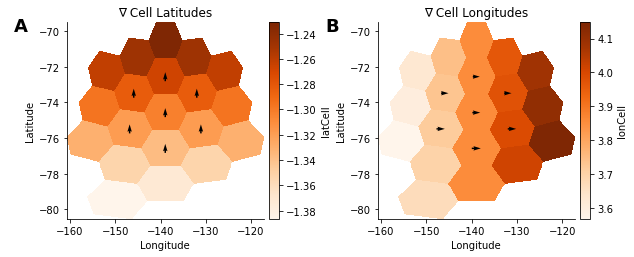

In [109]:
#plotting gradient fields
def plot_gradient_vectors(uxda_grad, **kwargs):
    """
    Plots gradient vectors using HoloViews
    """
    uxgrid = uxda_grad.uxgrid
    mag = np.hypot(uxda_grad.zonal_gradient, uxda_grad.meridional_gradient)
    angle = np.arctan2(uxda_grad.meridional_gradient, uxda_grad.zonal_gradient)

    return hv.VectorField(
        (uxgrid.face_lon, uxgrid.face_lat, angle, mag), **kwargs
    ).opts(magnitude="Magnitude")

p1 = (
    uxds["latCell"].subset.bounding_circle(center_coord, r).plot(cmap="Oranges", aspect=1) * plot_gradient_vectors(grad_lat)
).opts(title="∇ Cell Latitudes")
p2 = (
    uxds["lonCell"].subset.bounding_circle(center_coord, r).plot(cmap="Oranges", aspect=1) * plot_gradient_vectors(grad_lon)
).opts(title="∇ Cell Longitudes")
# Compose all two plots in a 2 column layout
(p1 + p2).cols(2).opts(shared_axes=False)

In [ ]:
######################################
#READING STRUCTURED GRID

In [ ]:
#https://uxarray.readthedocs.io/en/latest/user-guide/

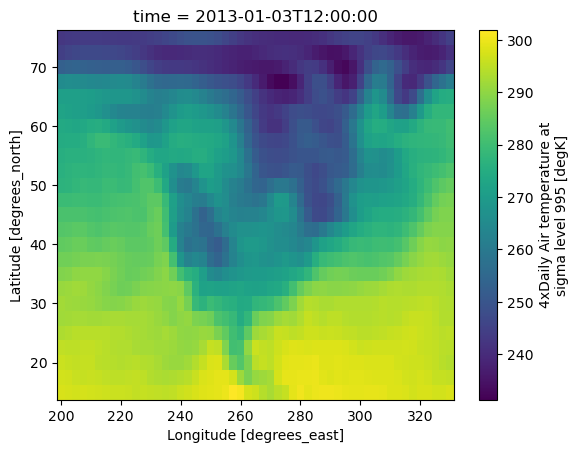

In [63]:
#get data
ds_air_temp = xr.tutorial.open_dataset("air_temperature")
ds_air_temp['air'].isel(time=10).plot()

In [67]:
#get structured grid
uxgrid = ux.Grid.from_structured(ds_air_temp) #OR #uxgrid = ux.Grid.from_structured(lon=ds_air_temp.lon, lat=ds_air_temp.lat)
uxgrid

<uxarray.Grid>
Original Grid Type: Structured
Grid Dimensions:
  * n_node: 1404
  * n_face: 1325
  * n_max_face_nodes: 4
Grid Coordinates (Spherical):
  * node_lon: (1404,)
  * node_lat: (1404,)
Grid Coordinates (Cartesian):
Grid Connectivity Variables:
  * face_node_connectivity: (1325, 4)
Grid Descriptor Variables:

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

:Overlay
   .Path.I      :Path   [Longitude,Latitude]
   .Coastline.I :Feature   [Longitude,Latitude]
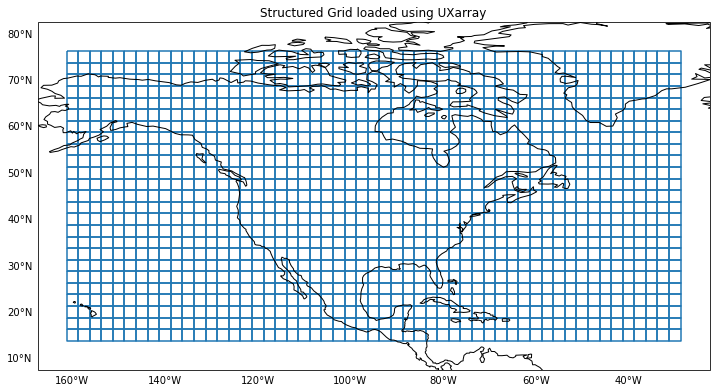

In [68]:
#plotting structured grid
uxgrid.plot(
    title="Structured Grid loaded using UXarray",
    backend="matplotlib",
    width=1000,
    coastline=True,
)

In [74]:
#converting to UxDataset
uxds = ux.UxDataset.from_structured(ds_air_temp)
uxds

<xarray.UxDataset> Size: 31MB
Dimensions:  (time: 2920, n_face: 1325)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
Dimensions without coordinates: n_face
Data variables:
    air      (time, n_face) float64 31MB 241.2 242.5 243.5 ... 296.5 296.2 295.7

:Overlay
   .Image.I     :Image   [Longitude,Latitude]   (Longitude_Latitude air)
   .Coastline.I :Feature   [Longitude,Latitude]
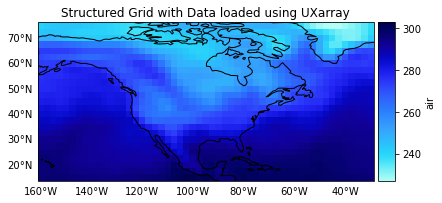

In [76]:
#plotting UxDataset
uxds["air"][0].plot(
    title="Structured Grid with Data loaded using UXarray",
    backend="matplotlib",
    width=500,
    coastline=True,
)